In [76]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv


# Machine Learning Project
Name: Abhishek Saha  
Roll: 23f1001572  

# Imports

In [77]:
import os
import gc
import numpy as np
import pandas as pd
from datetime import timedelta
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")


from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# Gradient boosting models
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor, Pool as CatPool


N_LGB_SEEDS = 20     
N_XGB_SEEDS = 5
N_CAT_SEEDS = 5 
LGB_ROUNDS = 1500
XGB_ROUNDS = 1200
CAT_ROUNDS = 1000
RND = 42

# EDA 

## Data Loading 

In [78]:
BASE = "/kaggle/input/Cinema_Audience_Forecasting_challenge/"

# BookNow platform datasets
df_visits_booknow       = pd.read_csv(os.path.join(BASE, "booknow_visits/booknow_visits.csv"))
df_bookings_booknow     = pd.read_csv(os.path.join(BASE, "booknow_booking/booknow_booking.csv"))
df_theaters_booknow     = pd.read_csv(os.path.join(BASE, "booknow_theaters/booknow_theaters.csv"))

# CinePOS datasets
df_bookings_cinepos     = pd.read_csv(os.path.join(BASE, "cinePOS_booking/cinePOS_booking.csv"))
df_theaters_cinepos     = pd.read_csv(os.path.join(BASE, "cinePOS_theaters/cinePOS_theaters.csv"))

# Supporting datasets
df_theater_mapping      = pd.read_csv(os.path.join(BASE, "movie_theater_id_relation/movie_theater_id_relation.csv"))
df_calendar_info        = pd.read_csv(os.path.join(BASE, "date_info/date_info.csv"))

# Sample submission
df_sample_submission    = pd.read_csv(os.path.join(BASE, "sample_submission/sample_submission.csv"))

## Shapes

In [79]:
print("BookNow datasets:")
print("  df_visits_booknow      :", df_visits_booknow.shape)
print("  df_bookings_booknow    :", df_bookings_booknow.shape)
print("  df_theaters_booknow    :", df_theaters_booknow.shape)

print("\nCinePOS datasets:")
print("  df_bookings_cinepos    :", df_bookings_cinepos.shape)
print("  df_theaters_cinepos    :", df_theaters_cinepos.shape)

print("\nSupporting datasets:")
print("  df_theater_mapping     :", df_theater_mapping.shape)
print("  df_calendar_info       :", df_calendar_info.shape)

print("\nSample submission:", df_sample_submission.shape)

BookNow datasets:
  df_visits_booknow      : (214046, 3)
  df_bookings_booknow    : (68336, 4)
  df_theaters_booknow    : (829, 5)

CinePOS datasets:
  df_bookings_cinepos    : (1641966, 4)
  df_theaters_cinepos    : (4690, 5)

Supporting datasets:
  df_theater_mapping     : (150, 2)
  df_calendar_info       : (547, 2)

Sample submission: (38062, 2)


In [80]:
print("\n BookNow: Visits ")
display(df_visits_booknow.head())

print("\n BookNow: Bookings ")
display(df_bookings_booknow.head())

print("\n BookNow: Theater Metadata ")
display(df_theaters_booknow.head())

print("\n CinePOS: Bookings ")
display(df_bookings_cinepos.head())

print("\n CinePOS: Theater Metadata ")
display(df_theaters_cinepos.head())

print("\n Theater Mapping ")
display(df_theater_mapping.head())

print("\n--- Calendar Info ---")
display(df_calendar_info.head())



 BookNow: Visits 


,book_theater_id,show_date,audience_count
0,book_00001,2023-01-13,50
1,book_00001,2023-01-14,64
2,book_00001,2023-01-15,58
3,book_00001,2023-01-16,44
4,book_00001,2023-01-18,12



 BookNow: Bookings 


,book_theater_id,show_datetime,booking_datetime,tickets_booked
0,book_00244,2023-01-01 19:00:00,2023-01-01 16:00:00,1
1,book_00740,2023-01-01 19:00:00,2023-01-01 19:00:00,3
2,book_00740,2023-01-01 19:00:00,2023-01-01 19:00:00,6
3,book_00244,2023-01-01 20:00:00,2023-01-01 16:00:00,2
4,book_00151,2023-01-01 20:00:00,2023-01-01 01:00:00,5



 BookNow: Theater Metadata 


...

,cine_theater_id,theater_type,theater_area,latitude,longitude
0,cinePOS_05466,Other,Area_104,22.619233,78.113017
1,cinePOS_08708,Other,Area_104,22.619233,78.113017
2,cinePOS_00753,Other,Area_104,22.619233,78.113017
3,cinePOS_05776,Other,Area_104,22.619233,78.113017
4,cinePOS_07536,Other,Area_104,23.004410,79.934515



 Theater Mapping 


,book_theater_id,cine_theater_id
0,book_00509,cinePOS_01261
1,book_00063,cinePOS_02467
2,book_00054,cinePOS_08923
3,book_00094,cinePOS_02479
4,book_00052,cinePOS_06750



--- Calendar Info ---


,show_date,day_of_week
0,2023-01-01,Sunday
1,2023-01-02,Monday
2,2023-01-03,Tuesday
3,2023-01-04,Wednesday
4,2023-01-05,Thursday


## Info- Feature Type

In [81]:
print("\n BookNow Visits ")
df_visits_booknow.info()

print("\n BookNow Bookings ")
df_bookings_booknow.info()

print("\n BookNow Theater Metadata ")
df_theaters_booknow.info()

print("\n CinePOS Bookings ")
df_bookings_cinepos.info()

print("\n CinePOS Theater Metadata ")
df_theaters_cinepos.info()

print("\n Theater Mapping ")
df_theater_mapping.info()

print("\n Info: Calendar Info ")
df_calendar_info.info()



 BookNow Visits 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214046 entries, 0 to 214045
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   book_theater_id  214046 non-null  object
 1   show_date        214046 non-null  object
 2   audience_count   214046 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 4.9+ MB

 BookNow Bookings 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68336 entries, 0 to 68335
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   book_theater_id   68336 non-null  object
 1   show_datetime     68336 non-null  object
 2   booking_datetime  68336 non-null  object
 3   tickets_booked    68336 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 2.1+ MB

 BookNow Theater Metadata 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829 entries, 0 to 828
Data columns (total 5 columns):
 #   C

## Missing Value Summary

In [82]:
datasets = {
    "BookNow_Visits": df_visits_booknow,
    "BookNow_Bookings": df_bookings_booknow,
    "BookNow_Theaters": df_theaters_booknow,
    "CinePOS_Bookings": df_bookings_cinepos,
    "CinePOS_Theaters": df_theaters_cinepos,
    "Mapping": df_theater_mapping,
    "Calendar": df_calendar_info
}

for name, df in datasets.items():
    print(f"{name}: {df.isna().sum().sum()} missing values")

BookNow_Visits: 0 missing values
BookNow_Bookings: 0 missing values
BookNow_Theaters: 515 missing values
CinePOS_Bookings: 0 missing values
CinePOS_Theaters: 7722 missing values
Mapping: 0 missing values
Calendar: 0 missing values


### Missing Values Across All Datasets

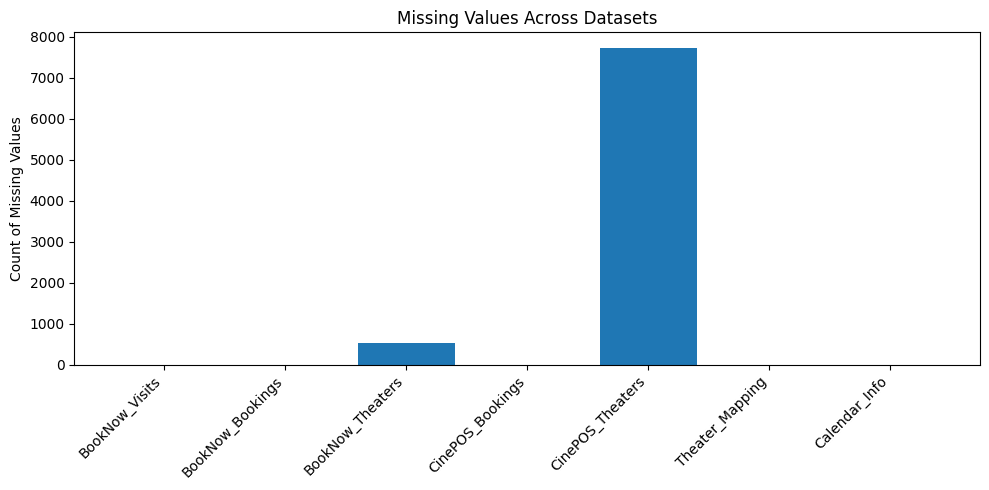

In [83]:
datasets = {
    'BookNow_Visits': df_visits_booknow,
    'BookNow_Bookings': df_bookings_booknow,
    'BookNow_Theaters': df_theaters_booknow,
    
    'CinePOS_Bookings': df_bookings_cinepos,
    'CinePOS_Theaters': df_theaters_cinepos,
    
    'Theater_Mapping': df_theater_mapping,
    'Calendar_Info': df_calendar_info
}

missing_data = {name: df.isna().sum().sum() for name, df in datasets.items()}

plt.figure(figsize=(10, 5))
plt.bar(missing_data.keys(), missing_data.values())
plt.title("Missing Values Across Datasets")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Count of Missing Values")
plt.tight_layout()
plt.show()

## DESCRIPTIVE STATISTICS

In [84]:
print("\n BookNow_Visits ")
print(df_visits_booknow.describe())

print("\n BookNow_Bookings ")
print(df_bookings_booknow.describe(include='all'))

print("\n BookNow_Theaters ")
print(df_theaters_booknow.describe())

print("\n CinePOS_Bookings ")
print(df_bookings_cinepos.describe())

print("\n CinePOS_Theaters ")
print(df_theaters_cinepos.describe())

print("\n Mapping ")
print(df_theater_mapping.describe(include='all'))


 BookNow_Visits 
       audience_count
count   214046.000000
mean        41.616568
std         32.834918
min          2.000000
25%         18.000000
50%         34.000000
75%         58.000000
max       1350.000000

 BookNow_Bookings 
       book_theater_id        show_datetime     booking_datetime  \
count            68336                68336                68336   
unique             301                 3866                 6351   
top         book_00712  2023-12-24 19:00:00  2023-11-24 18:00:00   
freq              1832                  255                  106   
mean               NaN                  NaN                  NaN   
std                NaN                  NaN                  NaN   
min                NaN                  NaN                  NaN   
25%                NaN                  NaN                  NaN   
50%                NaN                  NaN                  NaN   
75%                NaN                  NaN                  NaN   
max             

## VISUALIZATIONS & INSIGHTS

### Distribution of Audience Count

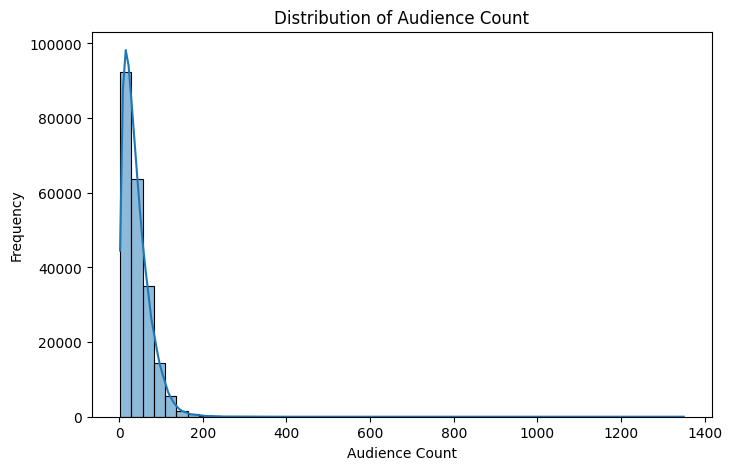

In [85]:
plt.figure(figsize=(8,5))
sns.histplot(df_visits_booknow["audience_count"], kde=True, bins=50)
plt.title("Distribution of Audience Count")
plt.xlabel("Audience Count")
plt.ylabel("Frequency")
plt.show()


##### Audience count is right-skewed; most shows have moderate attendance, with few high-audience outliers.

### Audience Trend Over Time (sample theater)

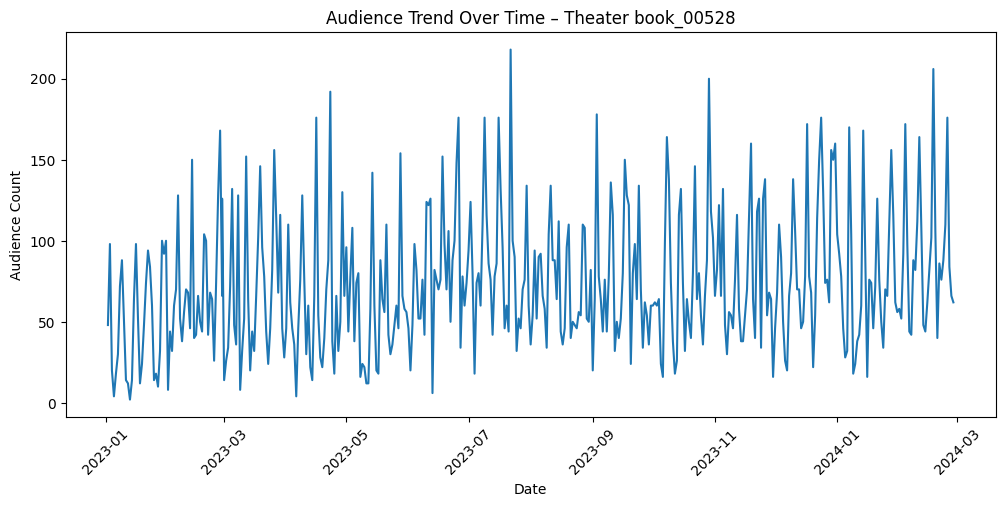

In [86]:
sample_theater = df_visits_booknow['book_theater_id'].value_counts().idxmax()

df_sample = df_visits_booknow[df_visits_booknow['book_theater_id'] == sample_theater].copy()
df_sample["show_date"] = pd.to_datetime(df_sample["show_date"])
df_sample = df_sample.sort_values("show_date")

plt.figure(figsize=(12,5))
plt.plot(df_sample["show_date"], df_sample["audience_count"])
plt.title(f"Audience Trend Over Time – Theater {sample_theater}")
plt.xlabel("Date")
plt.ylabel("Audience Count")
plt.xticks(rotation=45)
plt.show()


##### Daily audience shows variability and weekly patterns — useful for lag/rolling features.

### Average Audience by Day of Week

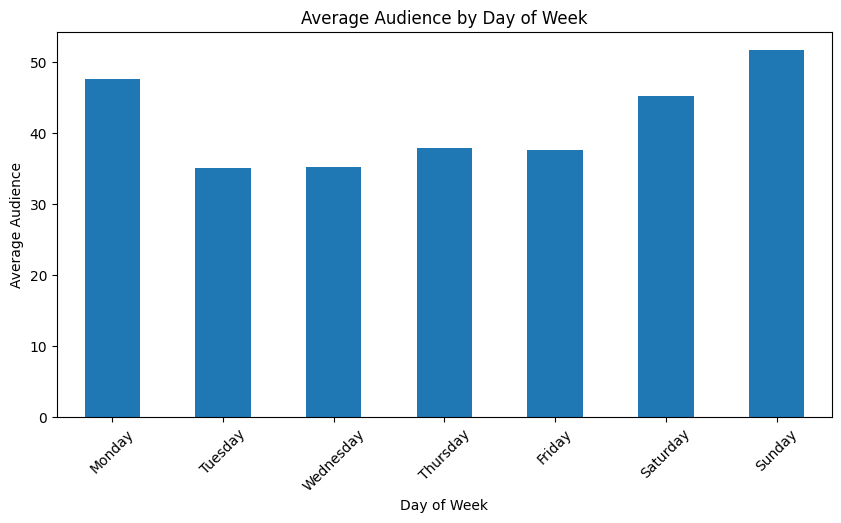

In [87]:
df_visits_booknow["show_date"] = pd.to_datetime(df_visits_booknow["show_date"])
df_calendar_info["show_date"] = pd.to_datetime(df_calendar_info["show_date"])

df_visits_calendar = df_visits_booknow.merge(df_calendar_info, on="show_date", how="left")
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plt.figure(figsize=(10,5))
df_visits_calendar.groupby("day_of_week")["audience_count"].mean().reindex(weekday_order).plot(kind="bar")
plt.title("Average Audience by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Audience")
plt.xticks(rotation=45)
plt.show()


##### Show frequency is highest on weekends (Saturday–Sunday), indicating stronger scheduling and audience engagement toward the end of the week.

### Monthly Average Audience

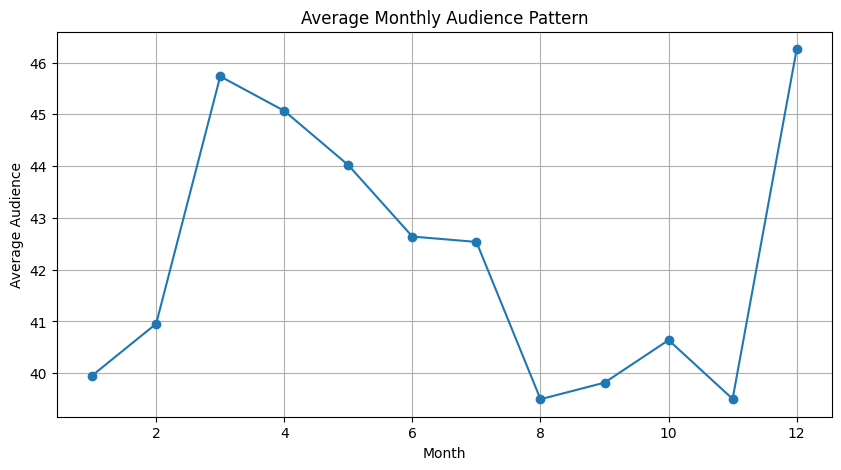

In [88]:
df_visits_calendar["month"] = df_visits_calendar["show_date"].dt.month

plt.figure(figsize=(10,5))
df_visits_calendar.groupby("month")["audience_count"].mean().plot(marker='o')
plt.title("Average Monthly Audience Pattern")
plt.xlabel("Month")
plt.ylabel("Average Audience")
plt.grid(True)
plt.show()


##### Show frequency is in the month March(3) and December(12)

### Audience by Theater Type

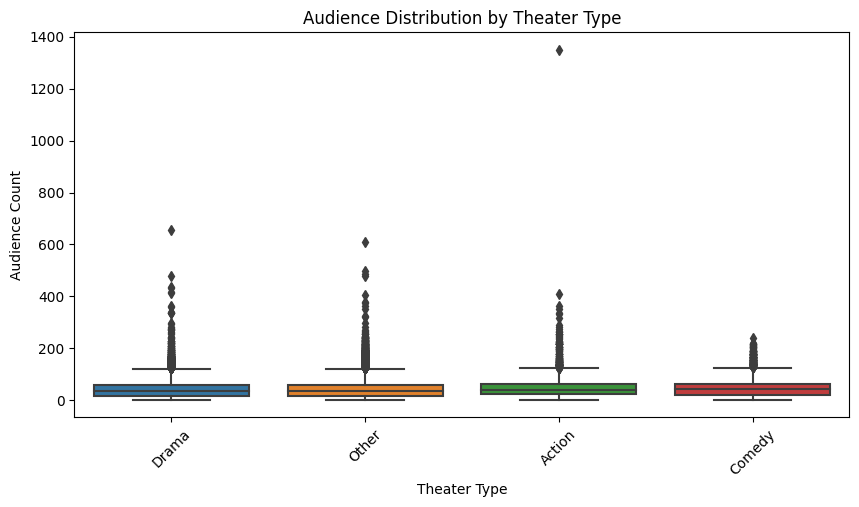

In [89]:
df_visits_meta = df_visits_booknow.merge(df_theaters_booknow, on="book_theater_id", how="left")

plt.figure(figsize=(10,5))
sns.boxplot(data=df_visits_meta, x="theater_type", y="audience_count")
plt.title("Audience Distribution by Theater Type")
plt.xlabel("Theater Type")
plt.ylabel("Audience Count")
plt.xticks(rotation=45)
plt.show()


##### Drama and Other theaters have the widest variation in audience levels, Action shows the largest spikes in demand, while Comedy theaters have more stable and lower median attendance.

### Top 15 Areas by Audience

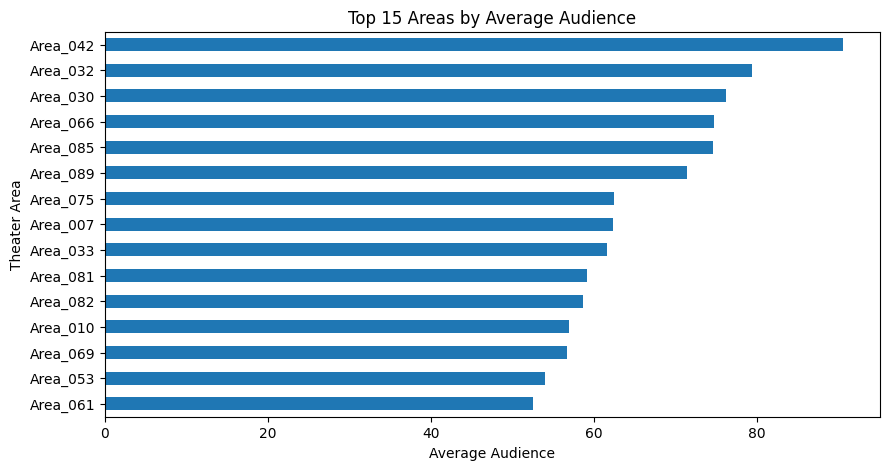

In [90]:
plt.figure(figsize=(10,5))
df_visits_meta.groupby("theater_area")["audience_count"].mean().sort_values(ascending=False).head(15).plot(kind="barh")
plt.title("Top 15 Areas by Average Audience")
plt.xlabel("Average Audience")
plt.ylabel("Theater Area")
plt.gca().invert_yaxis()
plt.show()


### Ticket Purchase Group Size — BookNow vs CinePOS (Percentage Comparison)

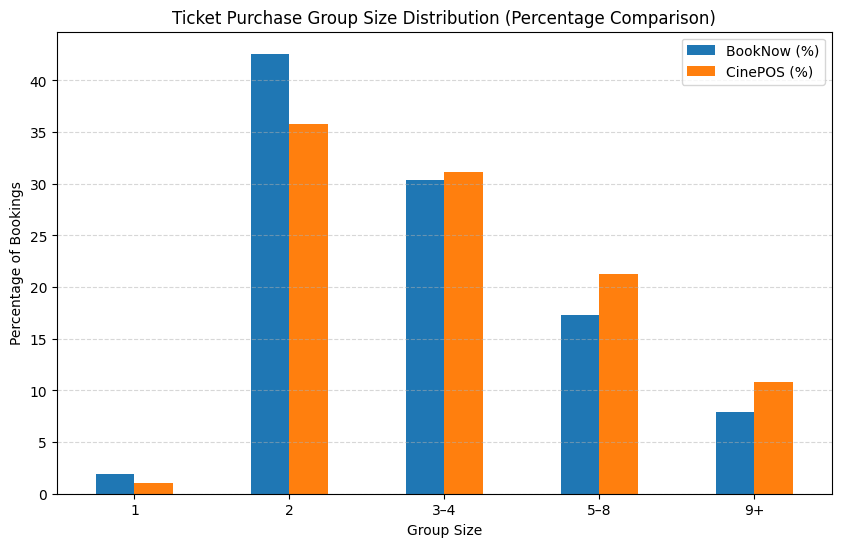

In [91]:
bn_counts = df_bookings_booknow["tickets_booked"]
cp_counts = df_bookings_cinepos["tickets_sold"]

bins = [0, 1, 2, 4, 8, 20]
labels = ["1", "2", "3–4", "5–8", "9+"]

bn_groups = pd.cut(bn_counts, bins=bins, labels=labels, include_lowest=True)
cp_groups = pd.cut(cp_counts, bins=bins, labels=labels, include_lowest=True)

bn_freq = bn_groups.value_counts().reindex(labels)
cp_freq = cp_groups.value_counts().reindex(labels)

bn_pct = (bn_freq / bn_freq.sum()) * 100
cp_pct = (cp_freq / cp_freq.sum()) * 100

compare_pct = pd.DataFrame({"BookNow (%)": bn_pct,"CinePOS (%)": cp_pct})

compare_pct.plot(kind="bar", figsize=(10,6))
plt.title("Ticket Purchase Group Size Distribution (Percentage Comparison)")
plt.xlabel("Group Size")
plt.ylabel("Percentage of Bookings")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


**Insights:**

- BookNow has a higher share of **1–2 ticket purchases**, suggesting individual or couple users.
- CinePOS has relatively more **3–4 and 5–8 ticket purchases**, indicating stronger group or family behavior.
- Percentage comparison helps remove the volume difference (CinePOS dataset is 20× bigger).


### Normalized Trend Comparison — BookNow vs CinePOS (Demand Pattern)

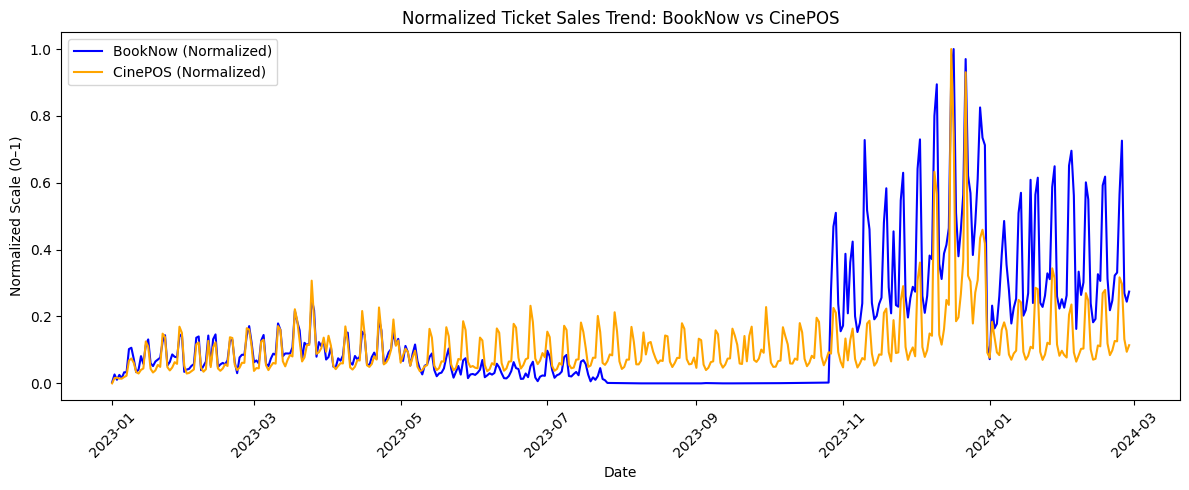

In [92]:
df_bookings_booknow["show_datetime"] = pd.to_datetime(df_bookings_booknow["show_datetime"])
df_bookings_cinepos["show_datetime"] = pd.to_datetime(df_bookings_cinepos["show_datetime"])

df_bookings_booknow["show_date"] = df_bookings_booknow["show_datetime"].dt.date
df_bookings_cinepos["show_date"] = df_bookings_cinepos["show_datetime"].dt.date

bn_daily = df_bookings_booknow.groupby("show_date")["tickets_booked"].sum().reset_index()
cp_daily = df_bookings_cinepos.groupby("show_date")["tickets_sold"].sum().reset_index()

bn_daily["norm"] = (bn_daily["tickets_booked"] - bn_daily["tickets_booked"].min()) / (bn_daily["tickets_booked"].max() - bn_daily["tickets_booked"].min())
cp_daily["norm"] = (cp_daily["tickets_sold"] - cp_daily["tickets_sold"].min()) / (cp_daily["tickets_sold"].max() - cp_daily["tickets_sold"].min())

plt.figure(figsize=(12,5))
plt.plot(bn_daily["show_date"], bn_daily["norm"], label="BookNow (Normalized)", color="blue")
plt.plot(cp_daily["show_date"], cp_daily["norm"], label="CinePOS (Normalized)", color="orange")
plt.title("Normalized Ticket Sales Trend: BookNow vs CinePOS")
plt.xlabel("Date")
plt.ylabel("Normalized Scale (0–1)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Both platforms show similar trend shapes despite different volumes, confirming strong external seasonality.

# FEATURE ENGINEERING

In [93]:
df_visits_booknow.columns   = df_visits_booknow.columns.str.strip()
df_theaters_booknow.columns = df_theaters_booknow.columns.str.strip()
df_calendar_info.columns    = df_calendar_info.columns.str.strip()
df_sample_submission.columns = df_sample_submission.columns.str.strip()

df_visits_booknow['show_date'] = pd.to_datetime(df_visits_booknow['show_date'])
df_calendar_info['show_date']  = pd.to_datetime(df_calendar_info['show_date'])
df = df_visits_booknow.copy()
df.head()

,book_theater_id,show_date,audience_count
0,book_00001,2023-01-13,50
1,book_00001,2023-01-14,64
2,book_00001,2023-01-15,58
3,book_00001,2023-01-16,44
4,book_00001,2023-01-18,12


In [94]:
q_lo = df['audience_count'].quantile(0.005)
q_hi = df['audience_count'].quantile(0.995)

print("Capping audience_count to:", q_lo, q_hi)
df['audience_count'] = df['audience_count'].clip(lower=q_lo, upper=q_hi)

df.head()

Capping audience_count to: 2.0 164.0


,book_theater_id,show_date,audience_count
0,book_00001,2023-01-13,50
1,book_00001,2023-01-14,64
2,book_00001,2023-01-15,58
3,book_00001,2023-01-16,44
4,book_00001,2023-01-18,12


#### Merge theater metadata and calendar info

In [95]:
full = df.merge(df_theaters_booknow, on='book_theater_id', how='left')
full = full.merge(df_calendar_info, on='show_date', how='left')

full = full.sort_values(['book_theater_id', 'show_date']).reset_index(drop=True)

print("Merged FE shape:", full.shape)
full.head()

Merged FE shape: (214046, 8)


,book_theater_id,show_date,audience_count,theater_type,theater_area,latitude,longitude,day_of_week
0,book_00001,2023-01-13,50,Drama,Area_002,23.00441,79.934515,Friday
1,book_00001,2023-01-14,64,Drama,Area_002,23.00441,79.934515,Saturday
2,book_00001,2023-01-15,58,Drama,Area_002,23.00441,79.934515,Sunday
3,book_00001,2023-01-16,44,Drama,Area_002,23.00441,79.934515,Monday
4,book_00001,2023-01-18,12,Drama,Area_002,23.00441,79.934515,Wednesday


## BASIC DATE FEATURES

In [96]:
full['month'] = full['show_date'].dt.month
full['day_of_year'] = full['show_date'].dt.dayofyear

dow_map = {'Monday':0,'Tuesday':1,'Wednesday':2,'Thursday':3,'Friday':4,'Saturday':5,'Sunday':6}
full['dow'] = full['day_of_week'].map(dow_map)

full['is_weekend']   = (full['dow'] >= 5).astype(int)
full['is_peak_month'] = (full['month'] == 3).astype(int)

full.head()

,book_theater_id,show_date,audience_count,theater_type,theater_area,latitude,longitude,day_of_week,month,day_of_year,dow,is_weekend,is_peak_month
0,book_00001,2023-01-13,50,Drama,Area_002,23.00441,79.934515,Friday,1,13,4,0,0
1,book_00001,2023-01-14,64,Drama,Area_002,23.00441,79.934515,Saturday,1,14,5,1,0
2,book_00001,2023-01-15,58,Drama,Area_002,23.00441,79.934515,Sunday,1,15,6,1,0
3,book_00001,2023-01-16,44,Drama,Area_002,23.00441,79.934515,Monday,1,16,0,0,0
4,book_00001,2023-01-18,12,Drama,Area_002,23.00441,79.934515,Wednesday,1,18,2,0,0


## THEATER & AREA STATISTICS

In [97]:
# Mean / Std for each theater
theater_stats = (full.groupby('book_theater_id')['audience_count'].agg(['mean', 'std']).rename(columns={'mean': 'theater_mean', 'std': 'theater_std'}).reset_index())

full = full.merge(theater_stats, on='book_theater_id', how='left')

# Area-level
area_mean = (full.groupby('theater_area')['audience_count'].mean().rename('area_mean').reset_index())
full = full.merge(area_mean, on='theater_area', how='left')


global_median = full['audience_count'].median()
full['theater_mean'] = full['theater_mean'].fillna(global_median)
full['theater_std']  = full['theater_std'].fillna(full['theater_std'].median())
full['area_mean']    = full['area_mean'].fillna(global_median)

full.head()

,book_theater_id,show_date,audience_count,theater_type,theater_area,latitude,longitude,day_of_week,month,day_of_year,dow,is_weekend,is_peak_month,theater_mean,theater_std,area_mean
0,book_00001,2023-01-13,50,Drama,Area_002,23.00441,79.934515,Friday,1,13,4,0,0,47.05848,23.388397,39.189568
1,book_00001,2023-01-14,64,Drama,Area_002,23.00441,79.934515,Saturday,1,14,5,1,0,47.05848,23.388397,39.189568
2,book_00001,2023-01-15,58,Drama,Area_002,23.00441,79.934515,Sunday,1,15,6,1,0,47.05848,23.388397,39.189568
3,book_00001,2023-01-16,44,Drama,Area_002,23.00441,79.934515,Monday,1,16,0,0,0,47.05848,23.388397,39.189568
4,book_00001,2023-01-18,12,Drama,Area_002,23.00441,79.934515,Wednesday,1,18,2,0,0,47.05848,23.388397,39.189568


## THEATER x DAY-OF-WEEK MEAN

In [98]:
full['theater_dow'] = full['book_theater_id'] + "_" + full['dow'].astype(str)
theater_dow_mean = (full.groupby('theater_dow')['audience_count'].mean().rename('theater_dow_mean').reset_index())
full = full.merge(theater_dow_mean, on='theater_dow', how='left')

# Fill missing values
full['theater_dow_mean'] = full['theater_dow_mean'].fillna(full['theater_mean'])
full.head()

,book_theater_id,show_date,audience_count,theater_type,theater_area,latitude,longitude,day_of_week,month,day_of_year,dow,is_weekend,is_peak_month,theater_mean,theater_std,area_mean,theater_dow,theater_dow_mean
0,book_00001,2023-01-13,50,Drama,Area_002,23.00441,79.934515,Friday,1,13,4,0,0,47.05848,23.388397,39.189568,book_00001_4,43.719298
1,book_00001,2023-01-14,64,Drama,Area_002,23.00441,79.934515,Saturday,1,14,5,1,0,47.05848,23.388397,39.189568,book_00001_5,66.842105
2,book_00001,2023-01-15,58,Drama,Area_002,23.00441,79.934515,Sunday,1,15,6,1,0,47.05848,23.388397,39.189568,book_00001_6,59.758621
3,book_00001,2023-01-16,44,Drama,Area_002,23.00441,79.934515,Monday,1,16,0,0,0,47.05848,23.388397,39.189568,book_00001_0,19.600000
4,book_00001,2023-01-18,12,Drama,Area_002,23.00441,79.934515,Wednesday,1,18,2,0,0,47.05848,23.388397,39.189568,book_00001_2,38.618182


## LAG FEATURES

In [99]:
grp = full.groupby('book_theater_id')

full['lag_7'] = grp['audience_count'].shift(7)
full['lag_14'] = grp['audience_count'].shift(14)

# Fill missing lags
full['lag_7'] = full['lag_7'].fillna(full['theater_mean'])
full['lag_14'] = full['lag_14'].fillna(full['theater_mean'])
full.head()

,book_theater_id,show_date,audience_count,theater_type,theater_area,latitude,longitude,day_of_week,month,day_of_year,dow,is_weekend,is_peak_month,theater_mean,theater_std,area_mean,theater_dow,theater_dow_mean,lag_7,lag_14
0,book_00001,2023-01-13,50,Drama,Area_002,23.00441,79.934515,Friday,1,13,4,0,0,47.05848,23.388397,39.189568,book_00001_4,43.719298,47.05848,47.05848
1,book_00001,2023-01-14,64,Drama,Area_002,23.00441,79.934515,Saturday,1,14,5,1,0,47.05848,23.388397,39.189568,book_00001_5,66.842105,47.05848,47.05848
2,book_00001,2023-01-15,58,Drama,Area_002,23.00441,79.934515,Sunday,1,15,6,1,0,47.05848,23.388397,39.189568,book_00001_6,59.758621,47.05848,47.05848
3,book_00001,2023-01-16,44,Drama,Area_002,23.00441,79.934515,Monday,1,16,0,0,0,47.05848,23.388397,39.189568,book_00001_0,19.600000,47.05848,47.05848
4,book_00001,2023-01-18,12,Drama,Area_002,23.00441,79.934515,Wednesday,1,18,2,0,0,47.05848,23.388397,39.189568,book_00001_2,38.618182,47.05848,47.05848


## Rolling window features

In [100]:
for w in [3, 5, 7, 14, 30]:
    full[f'roll_{w}'] = (grp['audience_count'].apply(lambda x: x.shift(1).rolling(w, min_periods=1).mean()).reset_index(level=0, drop=True))
    full[f'roll_{w}'] = full[f'roll_{w}'].fillna(full['theater_mean'])

full.head()

,book_theater_id,show_date,audience_count,theater_type,theater_area,latitude,longitude,day_of_week,month,day_of_year,...,area_mean,theater_dow,theater_dow_mean,lag_7,lag_14,roll_3,roll_5,roll_7,roll_14,roll_30
0,book_00001,2023-01-13,50,Drama,Area_002,23.00441,79.934515,Friday,1,13,...,39.189568,book_00001_4,43.719298,47.05848,47.05848,47.058480,47.058480,47.058480,47.058480,47.058480
1,book_00001,2023-01-14,64,Drama,Area_002,23.00441,79.934515,Saturday,1,14,...,39.189568,book_00001_5,66.842105,47.05848,47.05848,50.000000,50.000000,50.000000,50.000000,50.000000
2,book_00001,2023-01-15,58,Drama,Area_002,23.00441,79.934515,Sunday,1,15,...,39.189568,book_00001_6,59.758621,47.05848,47.05848,57.000000,57.000000,57.000000,57.000000,57.000000
3,book_00001,2023-01-16,44,Drama,Area_002,23.00441,79.934515,Monday,1,16,...,39.189568,book_00001_0,19.600000,47.05848,47.05848,57.333333,57.333333,57.333333,57.333333,57.333333
4,book_00001,2023-01-18,12,Drama,Area_002,23.00441,79.934515,Wednesday,1,18,...,39.189568,book_00001_2,38.618182,47.05848,47.05848,55.333333,54.000000,54.000000,54.000000,54.000000


## Relative features

In [101]:
full['lag7_minus_mean'] = full['lag_7'] - full['theater_mean']
full['roll7_minus_mean'] = full['roll_7'] - full['theater_mean']

full.head()

,book_theater_id,show_date,audience_count,theater_type,theater_area,latitude,longitude,day_of_week,month,day_of_year,...,theater_dow_mean,lag_7,lag_14,roll_3,roll_5,roll_7,roll_14,roll_30,lag7_minus_mean,roll7_minus_mean
0,book_00001,2023-01-13,50,Drama,Area_002,23.00441,79.934515,Friday,1,13,...,43.719298,47.05848,47.05848,47.058480,47.058480,47.058480,47.058480,47.058480,0.0,0.000000
1,book_00001,2023-01-14,64,Drama,Area_002,23.00441,79.934515,Saturday,1,14,...,66.842105,47.05848,47.05848,50.000000,50.000000,50.000000,50.000000,50.000000,0.0,2.941520
2,book_00001,2023-01-15,58,Drama,Area_002,23.00441,79.934515,Sunday,1,15,...,59.758621,47.05848,47.05848,57.000000,57.000000,57.000000,57.000000,57.000000,0.0,9.941520
3,book_00001,2023-01-16,44,Drama,Area_002,23.00441,79.934515,Monday,1,16,...,19.600000,47.05848,47.05848,57.333333,57.333333,57.333333,57.333333,57.333333,0.0,10.274854
4,book_00001,2023-01-18,12,Drama,Area_002,23.00441,79.934515,Wednesday,1,18,...,38.618182,47.05848,47.05848,55.333333,54.000000,54.000000,54.000000,54.000000,0.0,6.941520


## Cyclical time features

In [102]:
# Yearly cycle
full['sin_doy'] = np.sin(2*np.pi * full['day_of_year'] / 365.25)
full['cos_doy'] = np.cos(2*np.pi * full['day_of_year'] / 365.25)

# Weekly cycle
full['sin_week'] = np.sin(2*np.pi * full['dow'] / 7)
full['cos_week'] = np.cos(2*np.pi * full['dow'] / 7)

# Monthly cycle
full['sin_month'] = np.sin(2*np.pi * full['month'] / 12)
full['cos_month'] = np.cos(2*np.pi * full['month'] / 12)

# Quarterly cycle
full['quarter'] = full['show_date'].dt.quarter
full['sin_quarter'] = np.sin(2*np.pi * full['quarter'] / 4)
full['cos_quarter'] = np.cos(2*np.pi * full['quarter'] / 4)

# Higher-frequency harmonic
full['sin_doy_2'] = np.sin(4*np.pi * full['day_of_year'] / 365.25)
full['cos_doy_2'] = np.cos(4*np.pi * full['day_of_year'] / 365.25)

print("Feature Engineering Completed. Shape:", full.shape)
full.head()

Feature Engineering Completed. Shape: (214046, 38)


,book_theater_id,show_date,audience_count,theater_type,theater_area,latitude,longitude,day_of_week,month,day_of_year,...,cos_doy,sin_week,cos_week,sin_month,cos_month,quarter,sin_quarter,cos_quarter,sin_doy_2,cos_doy_2
0,book_00001,2023-01-13,50,Drama,Area_002,23.00441,79.934515,Friday,1,13,...,0.975099,-0.433884,-0.900969,0.5,0.866025,1,1.0,6.123234e-17,0.432499,0.901634
1,book_00001,2023-01-14,64,Drama,Area_002,23.00441,79.934515,Saturday,1,14,...,0.971139,-0.974928,-0.222521,0.5,0.866025,1,1.0,6.123234e-17,0.463258,0.886224
2,book_00001,2023-01-15,58,Drama,Area_002,23.00441,79.934515,Sunday,1,15,...,0.966893,-0.781831,0.623490,0.5,0.866025,1,1.0,6.123234e-17,0.493468,0.869764
3,book_00001,2023-01-16,44,Drama,Area_002,23.00441,79.934515,Monday,1,16,...,0.962360,0.000000,1.000000,0.5,0.866025,1,1.0,6.123234e-17,0.523094,0.852275
4,book_00001,2023-01-18,12,Drama,Area_002,23.00441,79.934515,Wednesday,1,18,...,0.952442,0.974928,-0.222521,0.5,0.866025,1,1.0,6.123234e-17,0.580455,0.814292


# TEST DATA PREPARATION

### Extract book_theater_id and show_date from sample["ID"]

In [103]:
# Extract book_theater_id and show_date from ID format: "book_00001_2023-01-13"
test_idx = df_sample_submission['ID'].str.extract(r'(book_\d+)_(\d{4}-\d{2}-\d{2})')
test_idx.columns = ['book_theater_id', 'show_date']

# Convert date column
test_idx['show_date'] = pd.to_datetime(test_idx['show_date'])

# Keep original ID
test_idx['ID'] = df_sample_submission['ID'].values

test_idx.head()

,book_theater_id,show_date,ID
0,book_00001,2024-03-01,book_00001_2024-03-01
1,book_00001,2024-03-02,book_00001_2024-03-02
2,book_00001,2024-03-03,book_00001_2024-03-03
3,book_00001,2024-03-04,book_00001_2024-03-04
4,book_00001,2024-03-06,book_00001_2024-03-06


### Merge with theater and calendar info

In [104]:
test_df = test_idx.merge(df_theaters_booknow, on='book_theater_id', how='left')
test_df = test_df.merge(df_calendar_info, on='show_date', how='left')

test_df.head()

,book_theater_id,show_date,ID,theater_type,theater_area,latitude,longitude,day_of_week
0,book_00001,2024-03-01,book_00001_2024-03-01,Drama,Area_002,23.00441,79.934515,Friday
1,book_00001,2024-03-02,book_00001_2024-03-02,Drama,Area_002,23.00441,79.934515,Saturday
2,book_00001,2024-03-03,book_00001_2024-03-03,Drama,Area_002,23.00441,79.934515,Sunday
3,book_00001,2024-03-04,book_00001_2024-03-04,Drama,Area_002,23.00441,79.934515,Monday
4,book_00001,2024-03-06,book_00001_2024-03-06,Drama,Area_002,23.00441,79.934515,Wednesday


### Add theater-level stats (mean & std)

In [105]:
test_df = test_df.merge(theater_stats, on='book_theater_id', how='left')

# Fill missing values using safe defaults
test_df['theater_mean'] = test_df['theater_mean'].fillna(global_median)
test_df['theater_std'] = test_df['theater_std'].fillna(full['theater_std'].median())

test_df.head()

,book_theater_id,show_date,ID,theater_type,theater_area,latitude,longitude,day_of_week,theater_mean,theater_std
0,book_00001,2024-03-01,book_00001_2024-03-01,Drama,Area_002,23.00441,79.934515,Friday,47.05848,23.388397
1,book_00001,2024-03-02,book_00001_2024-03-02,Drama,Area_002,23.00441,79.934515,Saturday,47.05848,23.388397
2,book_00001,2024-03-03,book_00001_2024-03-03,Drama,Area_002,23.00441,79.934515,Sunday,47.05848,23.388397
3,book_00001,2024-03-04,book_00001_2024-03-04,Drama,Area_002,23.00441,79.934515,Monday,47.05848,23.388397
4,book_00001,2024-03-06,book_00001_2024-03-06,Drama,Area_002,23.00441,79.934515,Wednesday,47.05848,23.388397


### Basic date features for test set

In [106]:
test_df['dow'] = test_df['show_date'].dt.dayofweek
test_df['month'] = test_df['show_date'].dt.month
test_df['is_weekend'] = (test_df['dow'] >= 5).astype(int)
test_df['is_peak_month'] = (test_df['month'] == 3).astype(int)
test_df['day_of_year'] = test_df['show_date'].dt.dayofyear
test_df.head()

,book_theater_id,show_date,ID,theater_type,theater_area,latitude,longitude,day_of_week,theater_mean,theater_std,dow,month,is_weekend,is_peak_month,day_of_year
0,book_00001,2024-03-01,book_00001_2024-03-01,Drama,Area_002,23.00441,79.934515,Friday,47.05848,23.388397,4,3,0,1,61
1,book_00001,2024-03-02,book_00001_2024-03-02,Drama,Area_002,23.00441,79.934515,Saturday,47.05848,23.388397,5,3,1,1,62
2,book_00001,2024-03-03,book_00001_2024-03-03,Drama,Area_002,23.00441,79.934515,Sunday,47.05848,23.388397,6,3,1,1,63
3,book_00001,2024-03-04,book_00001_2024-03-04,Drama,Area_002,23.00441,79.934515,Monday,47.05848,23.388397,0,3,0,1,64
4,book_00001,2024-03-06,book_00001_2024-03-06,Drama,Area_002,23.00441,79.934515,Wednesday,47.05848,23.388397,2,3,0,1,66


### Cyclical date features (same as training)

In [107]:
test_df['sin_week'] = np.sin(2 * np.pi * test_df['dow'] / 7)
test_df['cos_week'] = np.cos(2 * np.pi * test_df['dow'] / 7)

test_df['sin_month'] = np.sin(2 * np.pi * test_df['month'] / 12)
test_df['cos_month'] = np.cos(2 * np.pi * test_df['month'] / 12)

test_df['quarter'] = test_df['show_date'].dt.quarter
test_df['sin_quarter'] = np.sin(2 * np.pi * test_df['quarter'] / 4)
test_df['cos_quarter'] = np.cos(2 * np.pi * test_df['quarter'] / 4)

test_df['sin_doy_2'] = np.sin(4 * np.pi * test_df['day_of_year'] / 365.25)
test_df['cos_doy_2'] = np.cos(4 * np.pi * test_df['day_of_year'] / 365.25)
test_df.head()

,book_theater_id,show_date,ID,theater_type,theater_area,latitude,longitude,day_of_week,theater_mean,theater_std,...,day_of_year,sin_week,cos_week,sin_month,cos_month,quarter,sin_quarter,cos_quarter,sin_doy_2,cos_doy_2
0,book_00001,2024-03-01,book_00001_2024-03-01,Drama,Area_002,23.00441,79.934515,Friday,47.05848,23.388397,...,61,-0.433884,-0.900969,1.0,6.123234e-17,1,1.0,6.123234e-17,0.863867,-0.503720
1,book_00001,2024-03-02,book_00001_2024-03-02,Drama,Area_002,23.00441,79.934515,Saturday,47.05848,23.388397,...,62,-0.974928,-0.222521,1.0,6.123234e-17,1,1.0,6.123234e-17,0.846029,-0.533137
2,book_00001,2024-03-03,book_00001_2024-03-03,Drama,Area_002,23.00441,79.934515,Sunday,47.05848,23.388397,...,63,-0.781831,0.623490,1.0,6.123234e-17,1,1.0,6.123234e-17,0.827189,-0.561923
3,book_00001,2024-03-04,book_00001_2024-03-04,Drama,Area_002,23.00441,79.934515,Monday,47.05848,23.388397,...,64,0.000000,1.000000,1.0,6.123234e-17,1,1.0,6.123234e-17,0.807371,-0.590044
4,book_00001,2024-03-06,book_00001_2024-03-06,Drama,Area_002,23.00441,79.934515,Wednesday,47.05848,23.388397,...,66,0.974928,-0.222521,1.0,6.123234e-17,1,1.0,6.123234e-17,0.764891,-0.644159


### Theater area mean (from training)

In [108]:
area_mean_dict = full.groupby('theater_area')['audience_count'].mean().to_dict()
area_mean_mean = full['audience_count'].mean()

test_df['area_mean'] = test_df['theater_area'].map(area_mean_dict).fillna(area_mean_mean)
test_df.head()

,book_theater_id,show_date,ID,theater_type,theater_area,latitude,longitude,day_of_week,theater_mean,theater_std,...,sin_week,cos_week,sin_month,cos_month,quarter,sin_quarter,cos_quarter,sin_doy_2,cos_doy_2,area_mean
0,book_00001,2024-03-01,book_00001_2024-03-01,Drama,Area_002,23.00441,79.934515,Friday,47.05848,23.388397,...,-0.433884,-0.900969,1.0,6.123234e-17,1,1.0,6.123234e-17,0.863867,-0.503720,39.189568
1,book_00001,2024-03-02,book_00001_2024-03-02,Drama,Area_002,23.00441,79.934515,Saturday,47.05848,23.388397,...,-0.974928,-0.222521,1.0,6.123234e-17,1,1.0,6.123234e-17,0.846029,-0.533137,39.189568
2,book_00001,2024-03-03,book_00001_2024-03-03,Drama,Area_002,23.00441,79.934515,Sunday,47.05848,23.388397,...,-0.781831,0.623490,1.0,6.123234e-17,1,1.0,6.123234e-17,0.827189,-0.561923,39.189568
3,book_00001,2024-03-04,book_00001_2024-03-04,Drama,Area_002,23.00441,79.934515,Monday,47.05848,23.388397,...,0.000000,1.000000,1.0,6.123234e-17,1,1.0,6.123234e-17,0.807371,-0.590044,39.189568
4,book_00001,2024-03-06,book_00001_2024-03-06,Drama,Area_002,23.00441,79.934515,Wednesday,47.05848,23.388397,...,0.974928,-0.222521,1.0,6.123234e-17,1,1.0,6.123234e-17,0.764891,-0.644159,39.189568


### Theater x DayOfWeek mean

In [109]:
test_df['theater_dow'] = test_df['book_theater_id'] + "_" + test_df['dow'].astype(str)

theater_dow_mean_dict = full.groupby('theater_dow')['audience_count'].mean().to_dict()
theater_dow_mean_mean = full['audience_count'].mean()

test_df['theater_dow_mean'] = test_df['theater_dow'].map(theater_dow_mean_dict).fillna(theater_dow_mean_mean)
test_df.head()

,book_theater_id,show_date,ID,theater_type,theater_area,latitude,longitude,day_of_week,theater_mean,theater_std,...,sin_month,cos_month,quarter,sin_quarter,cos_quarter,sin_doy_2,cos_doy_2,area_mean,theater_dow,theater_dow_mean
0,book_00001,2024-03-01,book_00001_2024-03-01,Drama,Area_002,23.00441,79.934515,Friday,47.05848,23.388397,...,1.0,6.123234e-17,1,1.0,6.123234e-17,0.863867,-0.503720,39.189568,book_00001_4,43.719298
1,book_00001,2024-03-02,book_00001_2024-03-02,Drama,Area_002,23.00441,79.934515,Saturday,47.05848,23.388397,...,1.0,6.123234e-17,1,1.0,6.123234e-17,0.846029,-0.533137,39.189568,book_00001_5,66.842105
2,book_00001,2024-03-03,book_00001_2024-03-03,Drama,Area_002,23.00441,79.934515,Sunday,47.05848,23.388397,...,1.0,6.123234e-17,1,1.0,6.123234e-17,0.827189,-0.561923,39.189568,book_00001_6,59.758621
3,book_00001,2024-03-04,book_00001_2024-03-04,Drama,Area_002,23.00441,79.934515,Monday,47.05848,23.388397,...,1.0,6.123234e-17,1,1.0,6.123234e-17,0.807371,-0.590044,39.189568,book_00001_0,19.600000
4,book_00001,2024-03-06,book_00001_2024-03-06,Drama,Area_002,23.00441,79.934515,Wednesday,47.05848,23.388397,...,1.0,6.123234e-17,1,1.0,6.123234e-17,0.764891,-0.644159,39.189568,book_00001_2,38.618182


### Recent Mean For Lag Approximation

In [110]:
last_train_day = full.loc[full['audience_count'].notna(), 'show_date'].max()
cutoff = last_train_day - timedelta(days=60)

recent = full[(full['audience_count'].notna()) & (full['show_date'] > cutoff)]
recent_stats = recent.groupby('book_theater_id')['audience_count'] \
                     .agg(['mean', 'median']) \
                     .rename(columns={'mean': 'recent_mean', 'median': 'recent_median'}) \
                     .reset_index()

test_df = test_df.merge(recent_stats, on='book_theater_id', how='left')
test_df['recent_mean'] = test_df['recent_mean'].fillna(test_df['theater_mean'])
test_df.head()

,book_theater_id,show_date,ID,theater_type,theater_area,latitude,longitude,day_of_week,theater_mean,theater_std,...,quarter,sin_quarter,cos_quarter,sin_doy_2,cos_doy_2,area_mean,theater_dow,theater_dow_mean,recent_mean,recent_median
0,book_00001,2024-03-01,book_00001_2024-03-01,Drama,Area_002,23.00441,79.934515,Friday,47.05848,23.388397,...,1,1.0,6.123234e-17,0.863867,-0.503720,39.189568,book_00001_4,43.719298,36.36,33.0
1,book_00001,2024-03-02,book_00001_2024-03-02,Drama,Area_002,23.00441,79.934515,Saturday,47.05848,23.388397,...,1,1.0,6.123234e-17,0.846029,-0.533137,39.189568,book_00001_5,66.842105,36.36,33.0
2,book_00001,2024-03-03,book_00001_2024-03-03,Drama,Area_002,23.00441,79.934515,Sunday,47.05848,23.388397,...,1,1.0,6.123234e-17,0.827189,-0.561923,39.189568,book_00001_6,59.758621,36.36,33.0
3,book_00001,2024-03-04,book_00001_2024-03-04,Drama,Area_002,23.00441,79.934515,Monday,47.05848,23.388397,...,1,1.0,6.123234e-17,0.807371,-0.590044,39.189568,book_00001_0,19.600000,36.36,33.0
4,book_00001,2024-03-06,book_00001_2024-03-06,Drama,Area_002,23.00441,79.934515,Wednesday,47.05848,23.388397,...,1,1.0,6.123234e-17,0.764891,-0.644159,39.189568,book_00001_2,38.618182,36.36,33.0


##### We cannot compute real lags for unseen future dates → use recent training trends

### Approximate Lag & Rolling Features

In [111]:
test_df['lag_7']  = test_df['recent_mean']
test_df['lag_14'] = test_df['recent_mean']

for w in [3, 5, 7, 14, 30]:
    test_df[f'roll_{w}'] = test_df['recent_mean']

# Relative features
test_df['lag7_minus_mean']  = test_df['lag_7'] - test_df['theater_mean']
test_df['roll7_minus_mean'] = test_df['roll_7'] - test_df['theater_mean']

# Cyclical DOY
test_df['sin_doy'] = np.sin(2 * np.pi * test_df['day_of_year'] / 365.25)
test_df['cos_doy'] = np.cos(2 * np.pi * test_df['day_of_year'] / 365.25)


print("Test Data Preparation Completed. Shape:", test_df.shape)

Test Data Preparation Completed. Shape: (38062, 40)


### LABEL ENCODING for categorical columns  (TRAIN + TEST)

In [112]:
cat_cols = []

if 'theater_area' in full.columns:
    cat_cols.append('theater_area')

if 'theater_type' in full.columns:
    cat_cols.append('theater_type')

for c in cat_cols:
    le = LabelEncoder()

    # Combine train + test 
    combined = pd.concat([full[c].astype(str),test_df[c].astype(str)], axis=0).fillna('NA')
    le.fit(combined)  

    
    full[c] = le.transform(full[c].astype(str).fillna('NA'))
    test_df[c] = le.transform(test_df[c].astype(str).fillna('NA'))

print("Label Encoding completed for:", cat_cols)


Label Encoding completed for: ['theater_area', 'theater_type']


# Final Feature list

In [113]:
print(full.shape)
print(test_df.shape)

(214046, 38)
(38062, 40)


In [114]:
feature_cols = [
    'dow', 'month', 'is_weekend', 'is_peak_month',
    'theater_mean', 'area_mean', 'theater_std', 'theater_dow_mean',
    'lag_7', 'lag_14',
    'roll_3', 'roll_5', 'roll_7', 'roll_14', 'roll_30',
    'lag7_minus_mean', 'roll7_minus_mean',
    'sin_doy', 'cos_doy',
    'sin_week', 'cos_week',
    'sin_month', 'cos_month',
    'quarter', 'sin_quarter', 'cos_quarter',
    'sin_doy_2', 'cos_doy_2']

# Add encoded categorical columns 
if 'theater_area' in full.columns:
    feature_cols.append('theater_area')

if 'theater_type' in full.columns:
    feature_cols.append('theater_type')

# Drop any feature that test_df does not have
missing_features = [f for f in feature_cols if f not in test_df.columns]

if missing_features:
    print("Dropping missing features:", missing_features)
    feature_cols = [f for f in feature_cols if f not in missing_features]

print("Final feature count:", len(feature_cols))
print("Features:", feature_cols)

Final feature count: 30
Features: ['dow', 'month', 'is_weekend', 'is_peak_month', 'theater_mean', 'area_mean', 'theater_std', 'theater_dow_mean', 'lag_7', 'lag_14', 'roll_3', 'roll_5', 'roll_7', 'roll_14', 'roll_30', 'lag7_minus_mean', 'roll7_minus_mean', 'sin_doy', 'cos_doy', 'sin_week', 'cos_week', 'sin_month', 'cos_month', 'quarter', 'sin_quarter', 'cos_quarter', 'sin_doy_2', 'cos_doy_2', 'theater_area', 'theater_type']


## final train and test matrices

In [115]:
train = full[full['audience_count'].notna()].copy()
X_train = train[feature_cols].copy()
y_train = train['audience_count'].copy()
X_test = test_df[feature_cols].copy()

print("X_train:", X_train.shape, "X_test:", X_test.shape)

X_train: (214046, 30) X_test: (38062, 30)


# Train-Validation Split

In [116]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print("Train shape:", X_tr.shape)
print("Validation shape:", X_val.shape)

Train shape: (171236, 30)
Validation shape: (42810, 30)


### Scaling for linear models ONLY

In [117]:
scaler = StandardScaler()

X_tr_scaled = scaler.fit_transform(X_tr)
X_val_scaled = scaler.transform(X_val)

# MODELS

## Baseline Model Comparision

The three baseline models we evaluate are:

• Linear Regression (with scaled features)
• Random Forest Regressor
• Extra Trees Regressor

We compare them using:
• MAE  — Mean Absolute Error (lower is better)
• R²   — Coefficient of Determination (higher is better)

In [118]:
baseline_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1)
}

baseline_results = []

for name, model in baseline_models.items():

    # Linear Regression uses scaled data
    if name == "Linear Regression":
        model.fit(X_tr_scaled, y_tr)
        y_pred_val = model.predict(X_val_scaled)

    # Tree models use unscaled data
    else:
        model.fit(X_tr, y_tr)
        y_pred_val = model.predict(X_val)

    mae = mean_absolute_error(y_val, y_pred_val)
    r2  = r2_score(y_val, y_pred_val)

    baseline_results.append({
        "Model": name,
        "Val MAE": mae,
        "Val R²": r2
    })

    print(f"{name}: MAE={mae:.4f} | R²={r2:.4f}")

baseline_df = pd.DataFrame(baseline_results).sort_values("Val MAE")
baseline_df

Linear Regression: MAE=13.5675 | R²=0.6179
Random Forest: MAE=13.5276 | R²=0.6223
Extra Trees: MAE=13.5244 | R²=0.6230


,Model,Val MAE,Val R²
2,Extra Trees,13.524363,0.622971
1,Random Forest,13.527567,0.622273
0,Linear Regression,13.567502,0.617899


#### Comparison Plot

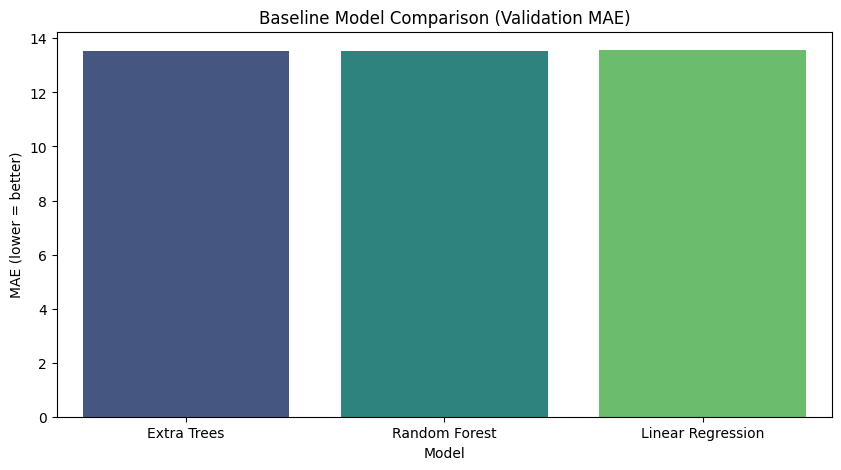

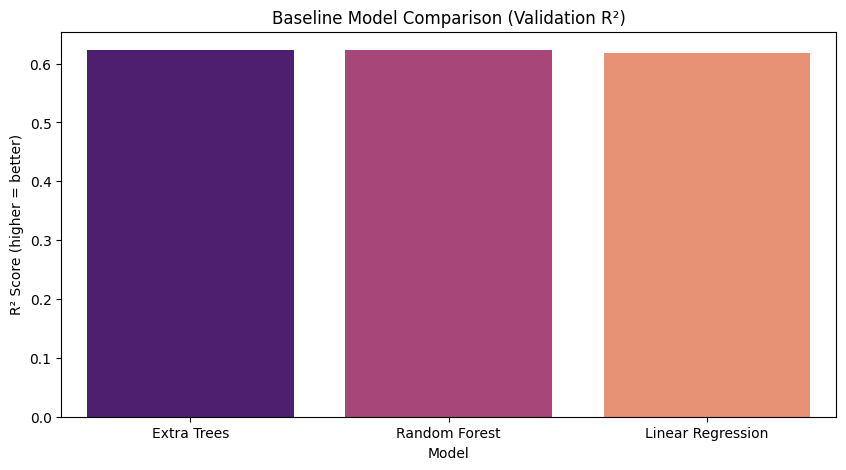

In [119]:
plt.figure(figsize=(10,5))
sns.barplot(data=baseline_df, x="Model", y="Val MAE", palette="viridis")
plt.title("Baseline Model Comparison (Validation MAE)")
plt.ylabel("MAE (lower = better)")
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(data=baseline_df, x="Model", y="Val R²", palette="magma")
plt.title("Baseline Model Comparison (Validation R²)")
plt.ylabel("R² Score (higher = better)")
plt.show()


#### Feature Importance from Extra Trees

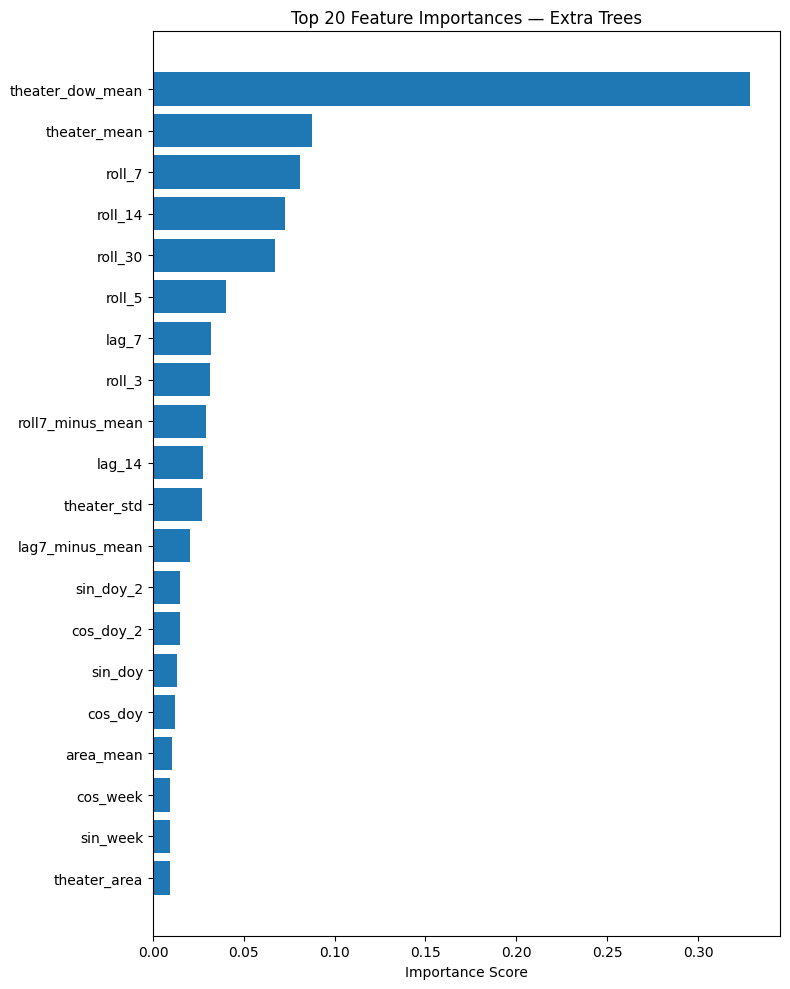

,Feature,Importance
7,theater_dow_mean,0.328686
4,theater_mean,0.087596
12,roll_7,0.080746
13,roll_14,0.072902
14,roll_30,0.067127
11,roll_5,0.040003
8,lag_7,0.032012
10,roll_3,0.031402
16,roll7_minus_mean,0.029426
9,lag_14,0.027338


In [120]:
et_model = ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1)
et_model.fit(X_tr, y_tr)

importances = et_model.feature_importances_
feature_imp_df = pd.DataFrame({
    "Feature": X_tr.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,10))
plt.barh(feature_imp_df["Feature"].head(20), feature_imp_df["Importance"].head(20))
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances — Extra Trees")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

feature_imp_df.head(20)

## LightGBM SEED AVERAGING (20 models)

In [121]:
X_tr_np = X_train.values
y_tr_np = y_train.values
X_te_np = X_test.values

lgb_preds = np.zeros((X_test.shape[0], N_LGB_SEEDS))

lgb_params = {
    'objective': 'regression',
    'metric': 'mae',
    'learning_rate': 0.05,
    'num_leaves': 48,
    'min_data_in_leaf': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbosity': -1   
}

for i, seed in enumerate(range(RND, RND + N_LGB_SEEDS)):
    print(f"LGB seed {i+1}/{N_LGB_SEEDS}: {seed}")
    
    lgb_params['seed'] = seed
    dtrain = lgb.Dataset(X_tr_np, label=y_tr_np)

    bst = lgb.train(params=lgb_params,train_set=dtrain,num_boost_round=LGB_ROUNDS)

    lgb_preds[:, i] = bst.predict(X_te_np, num_iteration=bst.best_iteration or None)

    del bst
    gc.collect()
    
# Average of 20 models gives stable predictions
lgb_mean = lgb_preds.mean(axis=1)
print("LightGBM seed averaging completed.")


LGB seed 1/20: 42
LGB seed 2/20: 43
LGB seed 3/20: 44
LGB seed 4/20: 45
LGB seed 5/20: 46
LGB seed 6/20: 47
LGB seed 7/20: 48
LGB seed 8/20: 49
LGB seed 9/20: 50
LGB seed 10/20: 51
LGB seed 11/20: 52
LGB seed 12/20: 53
LGB seed 13/20: 54
LGB seed 14/20: 55
LGB seed 15/20: 56
LGB seed 16/20: 57
LGB seed 17/20: 58
LGB seed 18/20: 59
LGB seed 19/20: 60
LGB seed 20/20: 61
LightGBM seed averaging completed.


## XGBOOST SEED AVERAGING (5 models)

In [122]:
xgb_preds = np.zeros((X_test.shape[0], N_XGB_SEEDS))

xgb_params = {'objective':'reg:squarederror','eta':0.05,'max_depth':6,'subsample':0.8,'colsample_bytree':0.8,'verbosity':0}

for i, seed in enumerate(range(RND+100, RND+100 + N_XGB_SEEDS)):
    print(f"XGB seed {i+1}/{N_XGB_SEEDS}: {seed}")
    xgb_params['seed'] = seed
    dtrain = xgb.DMatrix(X_tr_np, label=y_tr_np)
    bst = xgb.train(xgb_params, dtrain, num_boost_round=XGB_ROUNDS, verbose_eval=200)
    xgb_preds[:, i] = bst.predict(xgb.DMatrix(X_te_np))
    del bst
    gc.collect()

xgb_mean = xgb_preds.mean(axis=1)

print("XGB seed averaging completed.")

XGB seed 1/5: 142
XGB seed 2/5: 143
XGB seed 3/5: 144
XGB seed 4/5: 145
XGB seed 5/5: 146
XGB seed averaging completed.


## CATBOOST SEED AVERAGING (5 models)

In [123]:
cat_preds = np.zeros((X_test.shape[0], N_CAT_SEEDS))
for i, seed in enumerate(range(RND+200, RND+200 + N_CAT_SEEDS)):
    
    print(f"Cat seed {i+1}/{N_CAT_SEEDS}: {seed}")
    
    model = CatBoostRegressor(iterations=CAT_ROUNDS, learning_rate=0.03, depth=6, random_seed=seed, verbose=100)
    pool = CatPool(X_tr_np, label=y_tr_np)
    model.fit(pool, verbose=False)
    cat_preds[:, i] = model.predict(X_test)
    del model
    
    gc.collect()
    
cat_mean = cat_preds.mean(axis=1)
print("CATBOOST seed averaging completed.")

Cat seed 1/5: 242
Cat seed 2/5: 243
Cat seed 3/5: 244
Cat seed 4/5: 245
Cat seed 5/5: 246
CATBOOST seed averaging completed.


### FINAL WEIGHTED BLENDING

In [124]:
# 60% LGB, 20% XGB, 20% CAT
w_lgb, w_xgb, w_cat = 0.6, 0.2, 0.2
final_raw = w_lgb * lgb_mean + w_xgb * xgb_mean + w_cat * cat_mean

### SMOOTHING

In [127]:
# Add ensemble predictions
test_df['pred_raw'] = final_raw

# Smooth predictions per theater (3-day rolling mean)
test_df = test_df.sort_values(['book_theater_id', 'show_date'])
test_df['pred_smooth'] = (
    test_df.groupby('book_theater_id')['pred_raw']
           .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

# Final prediction
test_df['pred_final'] = (
    np.clip(np.round(test_df['pred_smooth']), 0, None).astype(int)
)

test_df.head()

,book_theater_id,show_date,ID,theater_type,theater_area,latitude,longitude,day_of_week,theater_mean,theater_std,...,roll_7,roll_14,roll_30,lag7_minus_mean,roll7_minus_mean,sin_doy,cos_doy,pred_raw,pred_smooth,pred_final
0,book_00001,2024-03-01,book_00001_2024-03-01,2,1,23.00441,79.934515,Friday,47.05848,23.388397,...,36.36,36.36,36.36,-10.69848,-10.69848,0.867099,0.498137,38.888415,38.888415,39
1,book_00001,2024-03-02,book_00001_2024-03-02,2,1,23.00441,79.934515,Saturday,47.05848,23.388397,...,36.36,36.36,36.36,-10.69848,-10.69848,0.875539,0.483147,63.412970,51.150693,51
2,book_00001,2024-03-03,book_00001_2024-03-03,2,1,23.00441,79.934515,Sunday,47.05848,23.388397,...,36.36,36.36,36.36,-10.69848,-10.69848,0.883720,0.468015,55.677757,52.659714,53
3,book_00001,2024-03-04,book_00001_2024-03-04,2,1,23.00441,79.934515,Monday,47.05848,23.388397,...,36.36,36.36,36.36,-10.69848,-10.69848,0.891640,0.452745,18.485046,45.858591,46
4,book_00001,2024-03-06,book_00001_2024-03-06,2,1,23.00441,79.934515,Wednesday,47.05848,23.388397,...,36.36,36.36,36.36,-10.69848,-10.69848,0.906686,0.421806,32.870899,35.677900,36


# Submission

In [128]:
# Build submission
pred_map = test_df[['ID', 'pred_final']].rename(columns={'pred_final': 'audience_count'})
submission = df_sample_submission.merge(pred_map, on='ID', how='left')

# Export
submission.to_csv("submission.csv", index=False)
print("submission.csv saved successfully!")



submission.csv saved successfully!


# End cell 
